In [6]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import polynomial
importlib.reload(polynomial)

<module 'polynomial' from '/mnt/d/GitRepos/NeuralXVA/error/polynomial.py'>

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


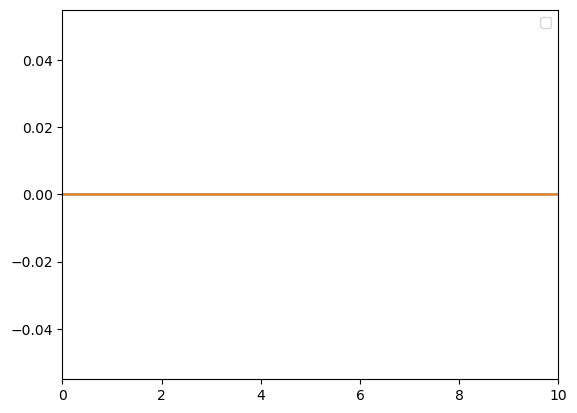

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


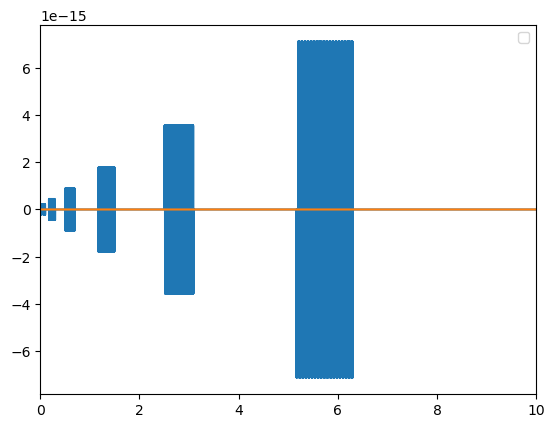

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


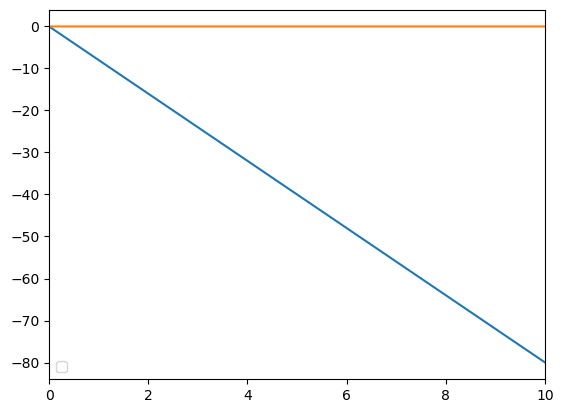

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


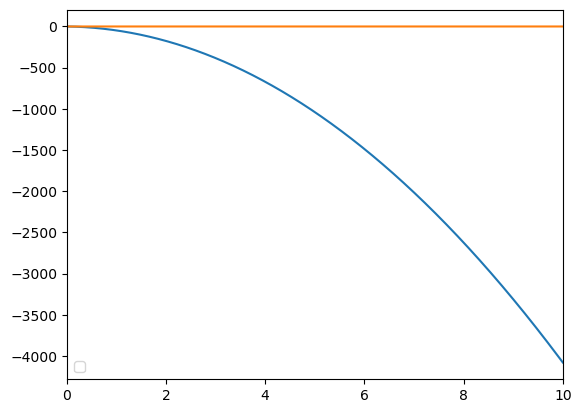

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


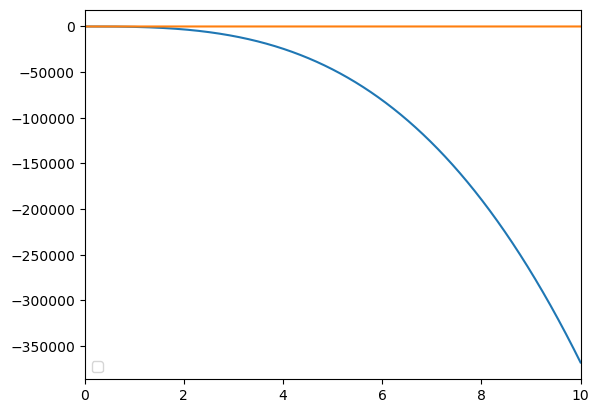

In [3]:
alpha = 0.75
m = 6
plot_range = 10
p = polynomial.error_poly(alpha, m)
x = np.arange(0, plot_range, 0.001, dtype=float)
for i in range(1, 6):
    lhs = p.p0(i, x) +  x * p.sum(0, i - 1, x) + x * p.sum(1, i - 1, x)
    rhs = (1 - alpha) * p.p1(i, x)
    #plt.plot(x, lhs, label='lhs')
    #plt.plot(x, rhs, label='rhs')
    plt.plot(x, rhs - lhs)
    plt.plot(x, np.zeros_like(x))
    # plt.plot(x, x * 2 * (1 + 1 / (1 - alpha)))
    plt.xlim(0, plot_range)
    #plt.ylim(0, 1000)
    plt.legend()
    plt.show()
    plt.close()

In [7]:
for i in range(5):
    print(p.p1(i + 1, np.ones(1)))

[4.]
[44.]
[412.]
[4124.]
[41244.]


In [7]:
n = 100
m = 20
delta_t = 1.0 / m
lambda_f = 1.0
alpha = 0.75

bound = polynomial.num_bound(lambda_f, delta_t, alpha, n, m)
bound.load_data(np.ones(n), np.ones(n))
bound.fill_error()

/tmp/ipykernel_1678/2606883791.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.plot(dummy, np.log10(bound.eepsilon))
/tmp/ipykernel_1678/2606883791.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(dummy, np.log10(bound.ee))


(0.0, 100.0)

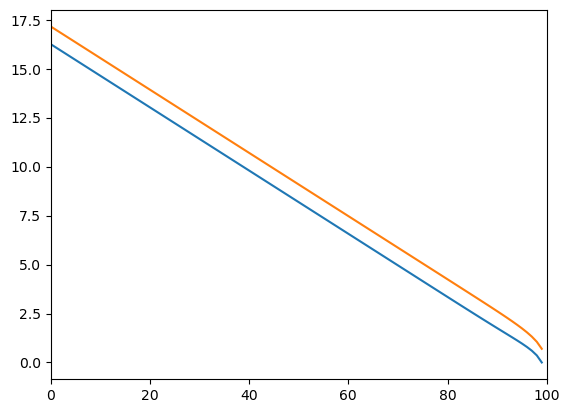

In [10]:
dummy = np.arange(0, n + 1)
plt.plot(dummy, np.log10(bound.eepsilon))
plt.plot(dummy, np.log10(bound.ee))
plt.xlim(dummy[0], dummy[-1])

/tmp/ipykernel_1678/2419086912.py:11: RuntimeWarning: divide by zero encountered in log10
  plt.plot(dummy, np.log10(bound.eepsilon))
/tmp/ipykernel_1678/2419086912.py:12: RuntimeWarning: divide by zero encountered in log10
  plt.plot(dummy, np.log10(bound.ee))


(0.0, 1.0)

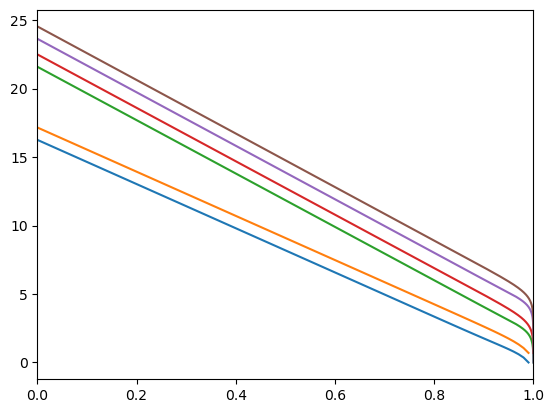

In [13]:
lambda_f = 1.0
alpha = 0.75

for n in (100, 10000, 1000000):
    m = int(n / 5)
    delta_t = 1.0 / m
    bound = polynomial.num_bound(lambda_f, delta_t, alpha, n, m)
    bound.load_data(np.ones(n), np.ones(n))
    bound.fill_error()
    dummy = np.arange(0, n + 1) / n
    plt.plot(dummy, np.log10(bound.eepsilon))
    plt.plot(dummy, np.log10(bound.ee))
plt.xlim(dummy[0], dummy[-1])